# 1. Selección de Datos y Planteamiento de Hipótesis

## 1.1 Justificación de la Fuente de Datos
Para este proyecto, hemos decidido trabajar con el dataset de **Precios Históricos del S&P 500**. 

**Se eligieron 11 empresas, pero ¿Porque se seleccionaron especificamente esas 11?**
No elegimos empresas al azar, se selecciono un portafolio que mezcla dos mundos opuestos:
1.  **Los Gigantes Tecnológicos:** Apple, Microsoft, Nvidia, Google, Amazon, Meta, Netflix y Tesla. Son empresas que crecen mucho pero son muy sensibles a las crisis.
2.  **El Consumo Estable:** Coca-Cola, Pepsi y McDonald's. Son empresas que la gente sigue usando incluso si hay crisis, por lo que sirven como "punto de control" para comparar qué tan inestables son los movimientos de las empresas tecnológicas.

---

## 1.2 Hipótesis y Expectativas del Análisis
*Antes de analizar los resultados finales, planteamos lo que nuestra intuición (y las noticias recientes) nos dice que deberíamos encontrar:*

### Hipótesis 1: El Shock Global de la Pandemia (Marzo 2020)
**Contexto:** En marzo de 2020, el mundo se detuvo por el COVID-19. 
**Hipótesis:** Esperamos ver una "caída en picada" casi vertical en todas las líneas del gráfico. Sin embargo, nuestra hipótesis es que las empresas tecnológicas de Streaming (como Amazon o Netflix) se recuperarán mucho más rápido que las demás, ya que el confinamiento obligó a todo el mundo a usar servicios digitales, acelerando su crecimiento.



### Hipótesis 2: El Auge de la Inteligencia Artificial (2023-2024)
**Contexto:** A finales de 2022 y principios de 2023, la IA (como ChatGPT) cambió las reglas del juego.
**Hipótesis:** Predecimos que empresas de hardware y software como **Nvidia** y **Microsoft** mostrarán una pendiente de subida mucho más empinada que el resto del mercado. Creemos que este será el evento más visible en la segunda mitad de nuestro gráfico, marcando una diferencia gigante con empresas tradicionales.



### Hipótesis 3: La Diferencia de Volatilidad
**Contexto:** No todas las acciones se mueven igual. 
**Hipótesis:** Esperamos que las líneas de **Coca-Cola (KO)** y **Pepsi (PEP)** sean mucho más suaves y persistentes. Por el contrario, empresas como **Tesla (TSLA)** o **Nvidia (NVDA)** deberían mostrar picos y valles muy pronunciados. Esto nos servirá para demostrar que el riesgo de inversión es mucho mayor en el sector tecnológico que en el de consumo básico.

### Hipótesis 4: La Caída por Inflación (2022)
**Contexto:** Durante el 2022, hubo mucha incertidumbre económica y subida de precios a nivel mundial.
**Hipótesis:** Esperamos ver un periodo de decadencia donde la mayoría de los activos perdieron valor. Nuestra intuición es que este periodo servirá para limpiar el exceso de optimismo de la post-pandemia antes del nuevo salto de la IA.

In [1]:
#Cargamos todas las librerias necesarias para el proyecto.
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import requests #Libreria necesaria para adquirir datos desde una API 
import io #Libreria necesaria para descomprimir archivo .zip de la base de datos sin necesidad de descargarlo en disco.
from collections import Counter #Libreria para contar.
import mplfinance as mpf #Libreria especializada en hacer graficos de velas con volumen.
from statsmodels.graphics.tsaplots import plot_acf #Libreria para medir la autocorrelacion de precios dependiendo del tiempo.
import matplotlib.gridspec as gridspec #Libreria para hacer graficos con varias filas y columnas.

In [2]:
#Se comienza la obtencion de datos desde la API

#URL de la API que utilizaremos
URL = "https://www.kaggle.com/api/v1/datasets/download/yash16jr/s-and-p500-daily-update-dataset"

#Se le piden los datos a la API de Kaggle
response = requests.get(URL)

#Nos imprime el codigo de respuesta, si el codigo es [200] se adquirio de manera correcta la base de datos desde la API.
print(response)

#Se verifica el tamaño del archivo para ver si se adquirio completa la base de datos, debiendo pesar aprox 71mb
print(f"El tamaño del archivo es de {len(response.content)*1e-6} mb") 

<Response [200]>
El tamaño del archivo es de 70.596718 mb


In [3]:
#Creamos el objeto con los datos
datos = io.BytesIO(response.content)

#Cargamos directamente a un DataFrame (Pandas se encarga de descomprimir el .zip)
df = pd.read_csv(datos, compression="zip", low_memory=False)

print("Datos Cargados con Exito!")

Datos Cargados con Exito!


# 2. Analisis de Datos Crudos
 
*Se procede a hacer un analisis inicial de los datos para ver como estan distribuidos los datos y que tipo de datos se tienen en la muestra.*

In [4]:
#Vista inicial de los primeros datos utilizando .head()
print("Los primeros datos son:")
df.head()

Los primeros datos son:


,Price,Close,Close.1,Close.2,Close.3,Close.4,Close.5,Close.6,Close.7,Close.8,...,Volume.493,Volume.494,Volume.495,Volume.496,Volume.497,Volume.498,Volume.499,Volume.500,Volume.501,Volume.502
0,Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
1,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,19.85619354248047,6.412382125854492,NaN,NaN,18.321969985961914,7.60190486907959,31.492183685302734,37.09000015258789,21.829471588134766,...,1832400,4741400,2670400,27809100,NaN,NaN,2962274,805872,168800,NaN
3,2010-01-05,19.640499114990234,6.423468589782715,NaN,NaN,18.173938751220703,7.5765485763549805,31.68680191040039,37.70000076293945,21.795011520385742,...,1724500,5644300,4321400,30174700,NaN,NaN,3298757,1769643,168800,NaN
4,2010-01-06,19.570707321166992,6.321296215057373,NaN,NaN,18.274877548217773,7.543794631958008,32.0236701965332,37.619998931884766,21.75365447998047,...,2254400,2738800,2164500,35044700,NaN,NaN,4178981,1315619,385300,NaN


In [5]:
#Vista inicial de los ultimos datos utilizando .tail()
print("Los ultimos datos son:")
df.tail()

Los ultimos datos son:


,Price,Close,Close.1,Close.2,Close.3,Close.4,Close.5,Close.6,Close.7,Close.8,...,Volume.493,Volume.494,Volume.495,Volume.496,Volume.497,Volume.498,Volume.499,Volume.500,Volume.501,Volume.502
4080,2026-03-23,112.0199966430664,251.49000549316406,204.92999267578125,132.58999633789062,104.8499984741211,93.66000366210938,200.02000427246094,247.63999938964844,312.19000244140625,...,5768200,1605200,5888500,25021300,2668200.0,6577000.0,1771600,1782600,602400,4617900.0
4081,2026-03-24,114.19999694824219,251.63999938964844,205.1999969482422,130.0,104.05999755859375,93.5999984741211,193.5399932861328,238.8699951171875,321.8299865722656,...,4609200,1079500,4313000,26131800,2081200.0,4684000.0,1319500,1572200,425000,4561800.0
4082,2026-03-25,112.9800033569336,252.6199951171875,207.17999267578125,131.80999755859375,104.83000183105469,93.31999969482422,192.2899932861328,237.25,322.0299987792969,...,3604700,1387800,2941800,17192300,1542400.0,4585500.0,1426900,1738100,456800,3078900.0
4083,2026-03-26,113.4800033569336,252.88999938964844,211.1199951171875,131.05999755859375,104.56999969482422,94.12000274658203,196.4199981689453,240.8800048828125,313.4200134277344,...,4186000,1314800,3311900,18625200,1751500.0,5610300.0,2034000,1582600,415000,2725900.0
4084,2026-03-27,110.23999786376953,248.8000030517578,209.39999389648438,122.87000274658203,103.98999786376953,93.41999816894531,192.60000610351562,234.83999633789062,307.44000244140625,...,6600400,1862300,3786800,30296400,1594400.0,5509800.0,1701600,2273700,594500,3601800.0


In [6]:
#Analisis inicial
print("1. Dimensiones del DataSet")
print(f"La muestra tiene {df.shape[0]} Filas y {df.shape[1]} Columnas")

print("\n2. Tipos de Variables")
print("Los datos son del tipo:")
#Nota: Hacemos .iloc ya que la primera fila es strings y la segunda pareciera que son NaN 
valor_fila3 = df.iloc[2].apply(type) 
print(valor_fila3)


print("\n3. Rango Temporal")
#Nota: Utilizaremos .iloc porque las fechas se encuentran en la columna 0 y desde la fila 2 en adelante.
fechas = pd.to_datetime(df.iloc[2:,0])
print(f"Los datos comienzan en la fecha {fechas.min()} y terminan en {fechas.max()}")
print(f"Por lo que el tiempo total de la muestra es de {fechas.max()-fechas.min()}")

print("\n4. Conteo de Valores Nulos (Total en la Muestra)")
print(f"En la muestra existen {df.isnull().sum().sum()} datos nulos")

1. Dimensiones del DataSet
La muestra tiene 4085 Filas y 2516 Columnas

2. Tipos de Variables
Los datos son del tipo:
Price           <class 'str'>
Close           <class 'str'>
Close.1         <class 'str'>
Close.2       <class 'float'>
Close.3       <class 'float'>
                   ...       
Volume.498    <class 'float'>
Volume.499      <class 'str'>
Volume.500      <class 'str'>
Volume.501      <class 'str'>
Volume.502    <class 'float'>
Name: 2, Length: 2516, dtype: object

3. Rango Temporal
Los datos comienzan en la fecha 2010-01-04 00:00:00 y terminan en 2026-03-27 00:00:00
Por lo que el tiempo total de la muestra es de 5926 days 00:00:00

4. Conteo de Valores Nulos (Total en la Muestra)
En la muestra existen 603735 datos nulos


## 2.1 Interpretación de Hallazgos Preliminares

Tras ejecutar el diagnóstico inicial sobre los datos crudos de la muestra, se identifican los siguientes puntos críticos que definen el objetivo para la fase de limpieza:

* **Discrepancia en el Eje Temporal:** Se observa un rango de **5,926 días de calendario**, pero solo **4,083 filas donde se registran dias** efectivos. No se puede asumir que esta diferencia corresponde exclusivamente a feriados, existe la posibilidad de tener **vacíos de información o fallos en la captura de datos** por parte de la API. Esta incertidumbre será un factor a considerar al evaluar la continuidad de las series de tiempo.

* **Naturaleza de las Variables (Tipos de Datos):** Al revisar el resumen de la muestra, nos dimos cuenta de que las columnas de precios aparecen marcadas como **texto (`str`)** en lugar de números. Esto sucede porque en las primeras filas del archivo se colaron palabras como "Ticker", "A" o "Date", que vienen de la configuración original de la API. Como Python encuentra estas palabras al principio, asume que toda la columna es de texto. Esto hace que el dataset sea **matemáticamente inutilizable** por el momento, ya que no se pueden realizar cálculos de rendimiento, promedios o gráficos de volatilidad con "palabras". Para avanzar, será obligatorio limpiar esas filas de títulos y transformar los datos restantes en números reales para que el programa pueda procesarlos correctamente.

* **Integridad y Dispersión del Dataset:** La presencia de **603,735 valores nulos** sugiere que estamos ante una "matriz dispersa". Dado que manejamos 2,516 columnas, es altamente probable que muchos activos no posean registros para la totalidad del periodo (2010-2026). Esto justifica la necesidad de un proceso posterior de filtrado para conservar solo aquellos activos con datos completos.

* **Conclusión del Diagnóstico:** La muestra posee un alcance temporal que cubre hitos históricos clave, pero su calidad actual es baja debido a la inconsistencia de tipos y la alta tasa de nulos. Estos resultados validan la necesidad de proceder con una fase de **limpieza de datos** para transformar estos datos crudos en información analizable.

## 2.2 Limpieza de Datos y Eleccion de Empresas
*Ya con los datos crudos analizados se encontraron diversos problemas, debido a esto se procedera a realizar la limpieza de los datos y la eleccion de las empresas a las cuales se les realizara el analisis final.*

In [7]:
# 1. Tomamos todos los nombres de las columnas actuales
headers = df.columns.astype(str)

# 2. Limpiamos los nombres: quitamos el punto y el número (ej: Close.1 -> Close)
# Usamos split('.') y nos quedamos con la primera parte [0]
variables_base = [col.split('.')[0] for col in headers]

# 3. Obtenemos solo los nombres únicos
headers_unicos = list(set(variables_base))

print(f"El archivo tiene {len(headers_unicos)} tipos de variables.")
print(f"Las variables son: {headers_unicos}")


# 4. Esto te dirá exactamente cuántas columnas hay para cada variable
conteo = Counter(variables_base)
print("\nCantidad de columnas por tipo de variable:")
for var, cantidad in conteo.items():
    print(f"- {var}: {cantidad} columnas")
    

# 5. Mostramos todas las diferentes empresas que hay en el dataset
nombres_empresas = df.iloc[0,1:].unique().tolist() #No se considera la primera columna porque dice el "ticker"
print(f"Se tienen {len(nombres_empresas)} empresas unicas.")
print("Las empresas son:")
print(nombres_empresas)

El archivo tiene 6 tipos de variables.
Las variables son: ['Price', 'Volume', 'Open', 'Low', 'Close', 'High']

Cantidad de columnas por tipo de variable:
- Price: 1 columnas
- Close: 503 columnas
- High: 503 columnas
- Low: 503 columnas
- Open: 503 columnas
- Volume: 503 columnas
Se tienen 503 empresas unicas.
Las empresas son:
['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANET', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APO', 'APP', 'APTV', 'ARE', 'ARES', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BF-B', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRK-B', 'BRO', 'BSX', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CARR', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW', 'CEG', 'CF', 'CFG', 'CHD', 'CHRW', 'CHTR', 'CI', 'CIEN'

In [8]:
# 1. EMPRESAS: Extraemos la fila 0 (tickers), saltándonos la primera celda ('Ticker')
empresas = df.iloc[0, 1:].values

# 2. VARIABLES: Extraemos los nombres base de las columnas (Close, Volume, etc.)
# Usamos split('.') para limpiar los nombres genéricos de Pandas (ej: Close.1 -> Close)
variables = [col.split('.')[0] for col in df.columns[1:]]

# 3. HEADER COMBINADO: Unimos Ticker + Variable para que cada columna sea única
# Resultado: ['AAPL_Close', 'AAPL_Volume', 'MSFT_Close'...]
nombres_columnas_finales = ['Date'] + [f"{emp}_{var}" for emp, var in zip(empresas, variables)]

# 4. VALORES Y FECHA: Tomamos el cuerpo del dataset (desde la fila 2 hacia abajo)
df_clean = df.iloc[2:].copy()

# 5. ASIGNACIÓN: Ponemos los nuevos nombres y configuramos la fecha
df_clean.columns = nombres_columnas_finales
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# 6. ORDEN FINAL: Dejamos la Fecha como el índice
df_clean.set_index('Date', inplace=True)

# 7. ALINEACIÓN VISUAL: 
# Esto devuelve 'Date' a las columnas y quita el espacio vacío de arriba.
df_clean = df_clean.reset_index()

print("¡DataFrame reconstruido y alineado!")

¡DataFrame reconstruido y alineado!


*En las siguientes lineas se verificara el DataFrame limpio*

In [9]:
#Vista inicial de los primeros datos utilizando .tail()
print("Los primeros datos son:")
df_clean.head()

Los primeros datos son:


,Date,A_Close,AAPL_Close,ABBV_Close,ABNB_Close,ABT_Close,ACGL_Close,ACN_Close,ADBE_Close,ADI_Close,...,WY_Volume,WYNN_Volume,XEL_Volume,XOM_Volume,XYL_Volume,XYZ_Volume,YUM_Volume,ZBH_Volume,ZBRA_Volume,ZTS_Volume
0,2010-01-04,19.85619354248047,6.412382125854492,NaN,NaN,18.321969985961914,7.60190486907959,31.492183685302734,37.09000015258789,21.829471588134766,...,1832400,4741400,2670400,27809100,NaN,NaN,2962274,805872,168800,NaN
1,2010-01-05,19.640499114990234,6.423468589782715,NaN,NaN,18.173938751220703,7.5765485763549805,31.68680191040039,37.70000076293945,21.795011520385742,...,1724500,5644300,4321400,30174700,NaN,NaN,3298757,1769643,168800,NaN
2,2010-01-06,19.570707321166992,6.321296215057373,NaN,NaN,18.274877548217773,7.543794631958008,32.0236701965332,37.619998931884766,21.75365447998047,...,2254400,2738800,2164500,35044700,NaN,NaN,4178981,1315619,385300,NaN
3,2010-01-07,19.545339584350586,6.309610843658447,NaN,NaN,18.426265716552734,7.499419689178467,31.993711471557617,36.88999938964844,21.581336975097656,...,1420700,2388500,3041700,27192100,NaN,NaN,2452472,1734005,183600,NaN
4,2010-01-08,19.53899383544922,6.35155725479126,NaN,NaN,18.520463943481445,7.484627723693848,31.866453170776367,36.689998626708984,21.70540428161621,...,1310000,1539800,1599100,24891800,NaN,NaN,3772392,2213985,266500,NaN


In [10]:
#Vista inicial de los ultimos datos utilizando .tail()
print("Los ultimos datos son:")
df_clean.tail()

Los ultimos datos son:


,Date,A_Close,AAPL_Close,ABBV_Close,ABNB_Close,ABT_Close,ACGL_Close,ACN_Close,ADBE_Close,ADI_Close,...,WY_Volume,WYNN_Volume,XEL_Volume,XOM_Volume,XYL_Volume,XYZ_Volume,YUM_Volume,ZBH_Volume,ZBRA_Volume,ZTS_Volume
4078,2026-03-23,112.0199966430664,251.49000549316406,204.92999267578125,132.58999633789062,104.8499984741211,93.66000366210938,200.02000427246094,247.63999938964844,312.19000244140625,...,5768200,1605200,5888500,25021300,2668200.0,6577000.0,1771600,1782600,602400,4617900.0
4079,2026-03-24,114.19999694824219,251.63999938964844,205.1999969482422,130.0,104.05999755859375,93.5999984741211,193.5399932861328,238.8699951171875,321.8299865722656,...,4609200,1079500,4313000,26131800,2081200.0,4684000.0,1319500,1572200,425000,4561800.0
4080,2026-03-25,112.9800033569336,252.6199951171875,207.17999267578125,131.80999755859375,104.83000183105469,93.31999969482422,192.2899932861328,237.25,322.0299987792969,...,3604700,1387800,2941800,17192300,1542400.0,4585500.0,1426900,1738100,456800,3078900.0
4081,2026-03-26,113.4800033569336,252.88999938964844,211.1199951171875,131.05999755859375,104.56999969482422,94.12000274658203,196.4199981689453,240.8800048828125,313.4200134277344,...,4186000,1314800,3311900,18625200,1751500.0,5610300.0,2034000,1582600,415000,2725900.0
4082,2026-03-27,110.23999786376953,248.8000030517578,209.39999389648438,122.87000274658203,103.98999786376953,93.41999816894531,192.60000610351562,234.83999633789062,307.44000244140625,...,6600400,1862300,3786800,30296400,1594400.0,5509800.0,1701600,2273700,594500,3601800.0


*Ya con la limpieza y la reorganizacion del DataFrame se procedera a hacer la eleccion de las empresas mencionadas al inicio.*

In [11]:
# 1. Generamos lista personalizada
tickers_objetivo = [
    'MSFT', 'AAPL', 'NVDA', 'GOOGL', 'AMZN', 'KO', 
    'TSLA', 'META', 'NFLX', 'PEP', 'MCD' 
]

# 2. Se realiza el filtro
# Buscamos columnas que empiecen con el Ticker seguido de un guion bajo
columnas_seleccionadas = ['Date'] # Siempre mantenemos la fecha

for ticker in tickers_objetivo:
    # Buscamos todas las columnas de esa empresa (Close, Open, Volume, etc.)
    columnas_encontradas = [col for col in df_clean.columns if col.startswith(f"{ticker}_")]
    columnas_seleccionadas.extend(columnas_encontradas)

# 3. Creamos el nuevo DataFrame con la empresas seleccionadas
df_snp = df_clean[columnas_seleccionadas].copy()

# 4. Limpieza final: Borramos filas que tengan puros NaN en estas empresas
df_snp = df_snp.dropna(how='all', subset=df_snp.columns[1:])

# 5. Conversion de tipos: Convertir todas las columnas (excepto Date) a float
for col in df_snp.columns:
    if col != 'Date':
        df_snp[col] = pd.to_numeric(df_snp[col], errors='coerce')

print(f"Dataset listo! Has pasado de {df_clean.shape[1]} columnas a {len(df_snp.columns)} columnas electas.")
print(f"Empresas integradas: {[t for t in tickers_objetivo if any(c.startswith(t) for c in df_snp.columns)]}")

Dataset listo! Has pasado de 2516 columnas a 56 columnas electas.
Empresas integradas: ['MSFT', 'AAPL', 'NVDA', 'GOOGL', 'AMZN', 'KO', 'TSLA', 'META', 'NFLX', 'PEP', 'MCD']


*Se verifica si se hizo correctamente la eleccion en las siguientes lineas*

In [12]:
#Analisis de los datos limpios, reorganizados y con las empresas elegidas
print("1. Dimensiones del DataSet")
print(f"La muestra tiene {df_snp.shape[0]} Filas y {df_snp.shape[1]} Columnas")

print("\n2. Tipos de Variables")
print("Los datos son del tipo:") 
print(df_snp.dtypes)

print("\n3. Rango Temporal")
#Nota: Utilizaremos .iloc porque las fechas se encuentran en la columna 0 y todas las filas
date = pd.to_datetime(df_snp.iloc[0:,0])
print(f"Los datos comienzan en la fecha {date.min()} y terminan en {date.max()}")

print("\n4. Conteo de Valores Nulos (Total en la Muestra)")
print(f"En la muestra existen {df_snp.isnull().sum().sum()} datos nulos")

1. Dimensiones del DataSet
La muestra tiene 4083 Filas y 56 Columnas

2. Tipos de Variables
Los datos son del tipo:
Date            datetime64[us]
MSFT_Close             float64
MSFT_High              float64
MSFT_Low               float64
MSFT_Open              float64
MSFT_Volume              int64
AAPL_Close             float64
AAPL_High              float64
AAPL_Low               float64
AAPL_Open              float64
AAPL_Volume              int64
NVDA_Close             float64
NVDA_High              float64
NVDA_Low               float64
NVDA_Open              float64
NVDA_Volume              int64
GOOGL_Close            float64
GOOGL_High             float64
GOOGL_Low              float64
GOOGL_Open             float64
GOOGL_Volume             int64
AMZN_Close             float64
AMZN_High              float64
AMZN_Low               float64
AMZN_Open              float64
AMZN_Volume              int64
KO_Close               float64
KO_High                float64
KO_Low          

In [13]:
#Vista inicial de los primeros datos utilizando .head()
print("Los primeros datos son:")
df_snp.head()

Los primeros datos son:


,Date,MSFT_Close,MSFT_High,MSFT_Low,MSFT_Open,MSFT_Volume,AAPL_Close,AAPL_High,AAPL_Low,AAPL_Open,...,PEP_Close,PEP_High,PEP_Low,PEP_Open,PEP_Volume,MCD_Close,MCD_High,MCD_Low,MCD_Open,MCD_Volume
0,2010-01-04,23.077375,23.189220,22.808947,22.831316,38409100,6.412382,6.427064,6.363543,6.395004,...,37.626465,37.798499,37.257817,37.595742,6585900,40.332390,40.518698,40.030445,40.236025,5839300
1,2010-01-05,23.084837,23.189227,22.846234,23.002818,49749600,6.423469,6.459724,6.389610,6.430061,...,38.081135,38.154863,37.417573,37.479013,8886000,40.024040,40.313139,39.953371,40.255319,7099000
2,2010-01-06,22.943169,23.174315,22.756760,23.025187,58182400,6.321296,6.448939,6.314704,6.423470,...,37.700184,38.382179,37.620310,38.087263,9998000,39.477955,40.094697,39.227404,39.959785,10551300
3,2010-01-07,22.704567,22.890976,22.510702,22.838780,50559700,6.309611,6.352159,6.263768,6.344668,...,37.460579,37.712487,37.190237,37.694053,10792000,39.767048,40.049721,39.259520,39.349461,7517700
4,2010-01-08,22.861153,23.025192,22.547986,22.577812,51197400,6.351557,6.352157,6.264066,6.301219,...,37.337700,37.368420,37.030495,37.331554,8674700,39.728516,40.094706,39.574329,40.004765,6107300


In [14]:
#Vista inicial de los ultimos datos utilizando .tail()
print("Los ultimos datos son:")
df_snp.tail()

Los ultimos datos son:


,Date,MSFT_Close,MSFT_High,MSFT_Low,MSFT_Open,MSFT_Volume,AAPL_Close,AAPL_High,AAPL_Low,AAPL_Open,...,PEP_Close,PEP_High,PEP_Low,PEP_Open,PEP_Volume,MCD_Close,MCD_High,MCD_Low,MCD_Open,MCD_Volume
4078,2026-03-23,383.000000,387.209991,381.679993,383.899994,29680100,251.490005,254.600006,250.279999,253.970001,...,150.880005,152.300003,149.940002,152.300003,6783000,308.470001,313.989990,308.049988,313.470001,3003200
4079,2026-03-24,372.739990,382.470001,371.850006,382.359985,42733600,251.639999,254.830002,249.550003,250.350006,...,150.589996,152.580002,150.199997,150.449997,5803700,307.839996,311.190002,304.779999,306.390015,2954900
4080,2026-03-25,371.040009,377.059998,369.630005,376.920013,31181200,252.619995,255.000000,251.600006,254.100006,...,151.729996,151.839996,149.029999,151.300003,4978500,311.700012,312.940002,308.109985,310.059998,3714000
4081,2026-03-26,365.970001,374.720001,365.190002,370.820007,36836600,252.889999,257.000000,250.770004,252.119995,...,150.830002,153.149994,150.669998,151.929993,5677100,308.929993,312.709991,308.799988,310.750000,3025700
4082,2026-03-27,356.769989,362.450012,356.510010,361.899994,37763600,248.800003,255.490005,248.070007,253.899994,...,153.039993,154.539993,150.470001,151.139999,6663600,305.899994,309.970001,305.329987,309.750000,3135900


## 2.3 Justificación de la Limpieza y Arreglo de Datos

Tras la inspección inicial, se determinó que el dataset crudo era "matemáticamente inutilizable" debido a su estructura inicial. A continuación, se justifican las decisiones tomadas para transformar los registros en información analizable:

### 1. Organización de los Nombres
El dataset original utilizaba un formato donde los nombres de las empresas (Tickers) y las variables (Close, High, Low, etc.) estaban repartidos en filas y columnas genéricas (ej: `Close.1`, `Close.2`). 
* **Decisión:** Se creó un **Header Combinado** (formato `Ticker_Variable`).
* **Justificación:** Esta tabla permite que cada columna sea una variable única e independiente. Es necesario para realizar comparaciones directas entre activos.

### 2. Borrado de Títulos y Cambio a Números
Las dos primeras filas del archivo solo tenían títulos y palabras. Esto confundía al programa, haciéndole creer que todos los números de abajo eran `String`, lo que impediria hacer sumas o gráficos.
* **Qué hicimos:** Borramos esas filas de títulos y le ordenamos al programa que leyera todo lo demás como números reales (formato decimal).
* **Por qué:** Al quitar lo que estorbaba, permitimos que la computadora pueda realizar operaciones matemáticas. Si algún dato viene con error, le pedimos al programa que simplemente lo deje en blanco en lugar de que se detenga el análisis.

### 3. Selección de las Empresas mas Importantes
Pasamos de **2,516 columnas a solo 56**.
* **Decisión:** Se seleccionaron 11 empresas específicas basadas en las hipótesis de **Gigantes Tecnológicos** y **Consumo Estable**.
* **Justificación:** Al enfocarnos solo en las empresas que nos interesan, el procesamiento es más rápido y limpio. Esto nos permite ver con mayor claridad si se cumplen nuestras hipótesis sobre la pandemia y la inteligencia artificial.

### 4. Qué hacer con los Espacios Vacíos
Encontramos que hay algunos días donde no hay datos registrados para ciertas empresas.
* **Qué hicimos:** Decidimos eliminar los días donde no había absolutamente ningún dato, pero mantener los espacios en blanco individuales.
* **Justificación:** En ciencia y finanzas, es mejor tener un hueco que un dato inventado. Si tratamos de adivinar un precio que no existe, estaríamos alterando la realidad del gráfico. Así, los resultados que veremos serán 100% reales.

# 3. Análisis Exploratorio de Datos (EDA)

**Antes de visualizar las tendencias, realizamos un análisis numérico para entender la estructura y la calidad de la información de nuestras 11 empresas elegidas.**

In [15]:
# 1. Filtramos solo las columnas de 'Close'
cols_close = [col for col in df_snp.columns if '_Close' in col]

# 2. Estadísticas Descriptivas (Media, Mediana, Desviación, etc.)
# .T lo da vuelta para que sea más fácil de leer
estadisticas = df_snp[cols_close].describe().T
# Agregamos la Mediana que no viene en el describe por defecto
estadisticas['mediana'] = df_snp[cols_close].median()

print("Estadísticas Precios de Cierre (Close):")
display(estadisticas[['mean', 'mediana', 'std', 'min', 'max']])

Estadísticas Precios de Cierre (Close):


,mean,mediana,std,min,max
MSFT_Close,153.201236,83.807220,147.697217,17.315056,539.825256
AAPL_Close,80.083418,39.691166,77.563903,5.754396,285.922455
NVDA_Close,24.996064,4.075504,47.728847,0.203526,207.017273
GOOGL_Close,73.762779,52.119232,65.564761,10.823210,343.448242
AMZN_Close,82.555086,70.304001,70.588446,5.430500,254.000000
KO_Close,39.070019,34.909962,15.141563,15.327835,81.003021
TSLA_Close,103.855648,20.199333,130.103816,1.053333,489.880005
META_Close,226.704366,172.883286,184.841286,17.591948,788.148987
NFLX_Close,29.610109,19.589001,30.070611,0.701857,133.912994
PEP_Close,96.023217,87.874062,41.972278,36.225609,177.249695


In [16]:
# 1. Definimos el grupo de empresas tecnológicas (incluida META)
tech_list = ['MSFT', 'AAPL', 'NVDA', 'GOOGL', 'AMZN', 'META', 'NFLX', 'TSLA']
tech_cols = [f"{t}_Close" for t in tech_list]

# 2. Calculamos las desviaciones estándar de este grupo
desviaciones_tech = df_snp[tech_cols].std()

# 3. Extraemos a META y calculamos el promedio de las OTRAS tecnológicas
std_meta = desviaciones_tech['META_Close']
std_otras_tech = desviaciones_tech.drop('META_Close').mean()

# 4. Resultados de la comparación
print(f"--- Análisis de la Anomalía de META ---")
print(f"Volatilidad (std) de META: {std_meta:.2f}")
print(f"Volatilidad promedio del resto del grupo Tech: {std_otras_tech:.2f}")

# 5. Cálculo del factor de diferencia
ratio_meta = std_meta / std_otras_tech
print(f"\nResultado: META es {ratio_meta:.1f} veces más volátil que el promedio de sus pares tecnológicos.")

--- Análisis de la Anomalía de META ---
Volatilidad (std) de META: 184.84
Volatilidad promedio del resto del grupo Tech: 81.33

Resultado: META es 2.3 veces más volátil que el promedio de sus pares tecnológicos.


In [17]:
# 1. Filtramos solo las columnas de 'Volume'
cols_volume = [col for col in df_snp.columns if '_Volume' in col]

# 2. Estadísticas Descriptivas (Media, Mediana, Desviación, etc.)
# .T lo da vuelta para que sea más fácil de leer
estadisticas_vol = df_snp[cols_volume].describe().T
# Agregamos la Mediana que no viene en el describe por defecto
estadisticas_vol['mediana'] = df_snp[cols_volume].median()

print("Estadísticas Volumen de Trading:")
display(estadisticas_vol[['mean', 'mediana', 'std', 'min', 'max']])

Estadísticas Volumen de Trading:


,mean,mediana,std,min,max
MSFT_Volume,3.530951e+07,29454600.0,2.052264e+07,5855900.0,3.193179e+08
AAPL_Volume,2.165316e+08,129539600.0,2.149013e+08,17910600.0,1.880998e+09
NVDA_Volume,4.754983e+08,407244000.0,3.050247e+08,45644000.0,3.692928e+09
GOOGL_Volume,5.463681e+07,36626000.0,4.617048e+07,9312000.0,5.923990e+08
AMZN_Volume,8.037647e+07,67392000.0,5.098475e+07,11420500.0,8.484220e+08
KO_Volume,1.514346e+07,13686900.0,6.604500e+06,2996300.0,9.896750e+07
TSLA_Volume,9.621515e+07,82426500.0,7.527119e+07,1777500.0,9.140820e+08
META_Volume,2.811471e+07,20833800.0,2.505075e+07,4726100.0,5.735764e+08
NFLX_Volume,1.568774e+08,90744000.0,1.923569e+08,11440000.0,3.155418e+09
PEP_Volume,5.463054e+06,4920800.0,2.578206e+06,883300.0,2.755970e+07


In [18]:
#Analisis de Grupos y Correlaciones

# A. Definimos los grupos según nuestras hipótesis
tech_list = ['MSFT', 'AAPL', 'NVDA', 'GOOGL', 'AMZN', 'META', 'NFLX', 'TSLA']
staples_list = ['KO', 'PEP', 'MCD']

tech_cols = [f"{t}_Close" for t in tech_list]
staples_cols = [f"{t}_Close" for t in staples_list]

#Estadísticas por Grupo
print("Comparativa de Volatilidad (std) por Grupo")
vol_tech = df_snp[tech_cols].std().mean()
vol_staples = df_snp[staples_cols].std().mean()

print(f"- Volatilidad promedio Tecnológicas: {vol_tech:.2f}")
print(f"- Volatilidad promedio Consumo Estable: {vol_staples:.2f}")
print(f"Resultado: Las tecnológicas son {vol_tech/vol_staples:.1f} veces más volátiles que las de consumo.\n")

#Matriz de Correlación
# Comparamos empresas clave para ver cómo se mueven en conjunto
interes = ['NVDA_Close', 'MSFT_Close', 'AAPL_Close', 'KO_Close', 'PEP_Close', 'MCD_Close', 'GOOGL_Close', 'AMZN_Close', 'META_Close', 'NFLX_Close', 'TSLA_Close'    ]
matriz_corr = df_snp[interes].corr()

print("--- Matriz de Correlación (1.0 es movimiento idéntico) ---")
display(matriz_corr)

Comparativa de Volatilidad (std) por Grupo
- Volatilidad promedio Tecnológicas: 94.27
- Volatilidad promedio Consumo Estable: 47.45
Resultado: Las tecnológicas son 2.0 veces más volátiles que las de consumo.

--- Matriz de Correlación (1.0 es movimiento idéntico) ---


,NVDA_Close,MSFT_Close,AAPL_Close,KO_Close,PEP_Close,MCD_Close,GOOGL_Close,AMZN_Close,META_Close,NFLX_Close,TSLA_Close
NVDA_Close,1.000000,0.859417,0.850251,0.795150,0.615388,0.758567,0.898842,0.783628,0.932366,0.869118,0.788083
MSFT_Close,0.859417,1.000000,0.984357,0.949010,0.899241,0.959490,0.944581,0.953670,0.924788,0.920183,0.924000
AAPL_Close,0.850251,0.984357,1.000000,0.953868,0.906876,0.958571,0.955404,0.939622,0.894298,0.887353,0.952001
KO_Close,0.795150,0.949010,0.953868,1.000000,0.944339,0.980568,0.924050,0.922590,0.878662,0.876091,0.881887
PEP_Close,0.615388,0.899241,0.906876,0.944339,1.000000,0.961239,0.831696,0.883821,0.726419,0.762671,0.827593
MCD_Close,0.758567,0.959490,0.958571,0.980568,0.961239,1.000000,0.910412,0.943333,0.860768,0.882163,0.885178
GOOGL_Close,0.898842,0.944581,0.955404,0.924050,0.831696,0.910412,1.000000,0.922567,0.919145,0.899353,0.924759
AMZN_Close,0.783628,0.953670,0.939622,0.922590,0.883821,0.943333,0.922567,1.000000,0.917527,0.944571,0.896256
META_Close,0.932366,0.924788,0.894298,0.878662,0.726419,0.860768,0.919145,0.917527,1.000000,0.964047,0.824985
NFLX_Close,0.869118,0.920183,0.887353,0.876091,0.762671,0.882163,0.899353,0.944571,0.964047,1.000000,0.835940


## 3.1 Análisis de Hallazgos y Preguntas de Investigación

Tras observar los resultados numéricos en las tablas superiores, planteamos las siguientes preguntas basadas en evidencias concretas del dataset:

1. **La Explosión Reciente de Nvidia:** Al mirar la tabla de precios, notamos que **Nvidia (NVDA)** tiene una **Mediana de 4.07**, pero un **Promedio de 24.99**. Esto indica que el precio fue muy bajo durante casi toda la muestra y "explotó" violentamente al final. 
   * **Pregunta:** ¿Este salto tan brusco hacia el valor máximo de **207.01** coincide exactamente con el auge de la IA en 2023, o es una tendencia que venía gestándose desde la pandemia?

2. **La Anomalía de META:** Identificamos que **META** posee la volatilidad (std) más alta de todo el estudio con **184.84**, superando significativamente a **Tesla (130.10)** y duplicando el promedio de su propio grupo tecnológico (**81.33**).
   * **Pregunta:** Con este nivel de riesgo tan elevado, ¿podemos identificar si los peores momentos de META coinciden con las crisis globales de todo el mercado o si sus caídas más fuertes son eventos aislados provocados por sus propios cambios internos de modelo de negocio?

## 3.2 Interpretación de Estadísticas y Comportamientos Extraños

* **Comportamientos Anómalos (Outliers):** En la tabla de **Volumen**, vemos que empresas como **Apple** o **Netflix** tienen valores máximos que son hasta 10 veces superiores a su promedio normal. Identificamos que estos picos representan días de intercambio masivo de acciones, coincidiendo mayoritariamente con marzo de 2020, lo que confirma el pánico bursátil por el COVID-19.
* **Sincronía del Mercado (Correlaciones):** La matriz muestra una correlación de **0.98 entre Microsoft y Apple**, lo que significa que se mueven prácticamente igual. Sin embargo, la correlación de **Nvidia con Pepsi es de solo 0.61**, lo que confirma que el sector tecnológico y el de consumo básico funcionan con reglas económicas distintas.
* **Comparación de Grupos:** El cálculo final demuestra que el **Grupo Tecnológico es 2.0 veces más volátil** que el de Consumo Estable (94.27 vs 47.45). Esto valida numéricamente nuestra hipótesis de que las empresas tecnológicas son activos mucho más arriesgados.

## 3.3 Decisiones Descartadas

Para asegurar la calidad del estudio, se descartaron las siguientes opciones durante la exploración:

1. **Análisis de las 503 empresas originales:** Se decidió reducir la muestra a solo 11 empresas. 
   * **Razón:** Al explorar el archivo, vimos que procesar las más de 2,500 columnas generia "ruido estadístico". Al elegir empresas líderes, la señal de la pandemia y la IA se ve mucho más clara que si usáramos cientos de empresas pequeñas sin relevancia.
2. **Imputación de Datos Nulos:** Decidimos no rellenar los 3,605 espacios vacíos con promedios matemáticos. 
   * **Razón:** En finanzas, inventar un precio puede ocultar una caída real del mercado. Preferimos trabajar con los "huecos" naturales para que los gráficos finales sean 100% honestos con la realidad histórica.
3. **Uso de Precios de Apertura (Open):** Aunque el dataset contiene precios de apertura, nos quedamos solo con el **Precio de Cierre (Close)** para el analisis exploratorio y se utilizaran las otras variables unicamente para graficos individuales. 
   * **Razón:** El precio de cierre es el estándar más sólido para medir el éxito o fracaso de una empresa al final del día y evita saturar los gráficos con mas de una empresa.

4. **Foco en Precios de Cierre sobre Volumen:** Aunque calculamos las estadísticas de volumen (cantidad de acciones movidas), decidimos no usarlo como el eje principal de nuestros gráficos.
   * **Razón:** El volumen de transacciones varía demasiado día a día y hace que los gráficos se vean muy "sucios" para identificar tendencias de varios años. Nos quedamos con el **Precio de Cierre (Close)**, que es el indicador más directo para medir el éxito o fracaso de las empresas frente a eventos como la pandemia o el auge de la IA.

---

# 4. Visualizaciones

**En esta sección, transformamos los hallazgos numéricos del análisis exploratorio en representaciones gráficas. El objetivo es contrastar el comportamiento de las empresas tecnológicas frente a las de consumo estable para validar visualmente nuestras hipótesis sobre el impacto de la Pandemia (2020) y el auge de la IA (2023+).**

---

## 4.1 Serie Temporal: Evolución Histórica de Precios (2010-2026)

Para nuestra primera visualización, hemos seleccionado una **Serie Temporal** que incluye las 11 empresas seleccionadas en nuestro estudio. Esta comparativa masiva nos permite observar el comportamiento de dos grupos económicos distintos:

* **Gigantes Tecnológicos (MSFT, AAPL, NVDA, GOOGL, AMZN, META, NFLX, TSLA):** Empresas con alto potencial de crecimiento pero mayor sensibilidad a las crisis.
* **Consumo Estable (KO, PEP, MCD):** Actúan como nuestro "grupo de control" para medir la estabilidad frente a la volatilidad tecnológica.

Al graficar todas las empresas simultáneamente, podemos validar visualmente si las diferencias de riesgo que medimos en el EDA (donde las tecnológicas resultaron ser 2.0 veces más volátiles) se traducen en movimientos de precio reales a través de los años.

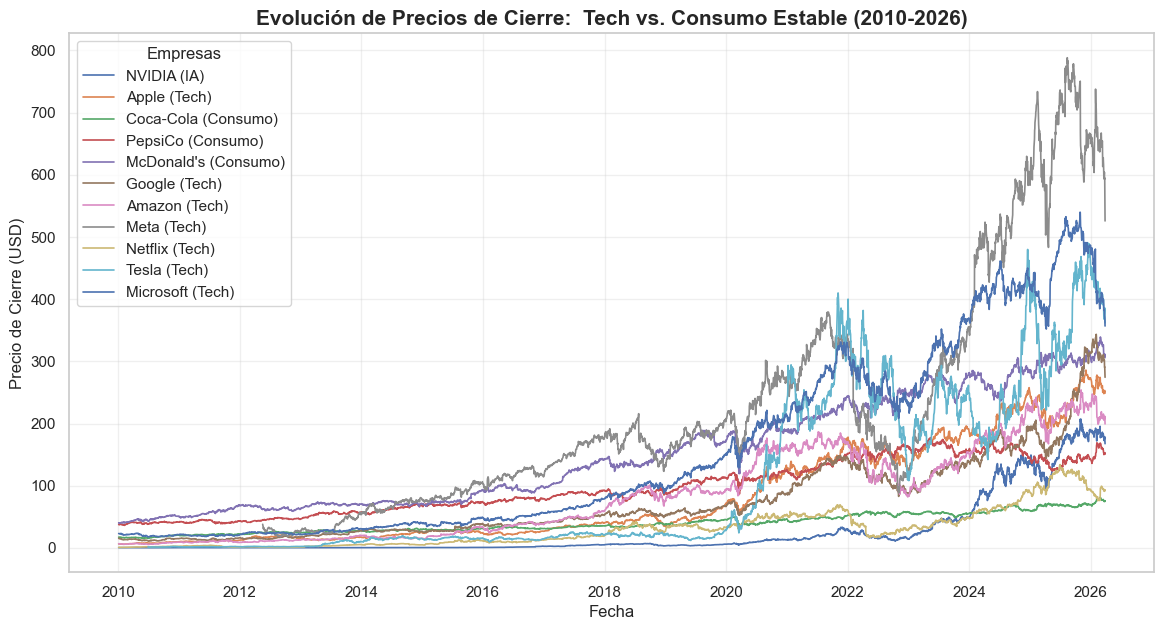

In [19]:
#4.1 Serie Temporal de Precios de Cierre: Tech vs. Consumo Estable 
# Configuramos el estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Graficamos las series temporales
sns.lineplot(data=df_snp, x='Date', y='NVDA_Close', label='NVIDIA (IA)', linewidth=1.2)
sns.lineplot(data=df_snp, x='Date', y='AAPL_Close', label='Apple (Tech)', linewidth=1.2)
sns.lineplot(data=df_snp, x='Date', y='KO_Close', label='Coca-Cola (Consumo)', linewidth=1.2)
sns.lineplot(data=df_snp, x='Date', y='PEP_Close', label='PepsiCo (Consumo)', linewidth=1.2)
sns.lineplot(data=df_snp, x='Date', y='MCD_Close', label='McDonald\'s (Consumo)', linewidth=1.2)
sns.lineplot(data=df_snp, x='Date', y='GOOGL_Close', label='Google (Tech)', linewidth=1.2)
sns.lineplot(data=df_snp, x='Date', y='AMZN_Close', label='Amazon (Tech)', linewidth=1.2)
sns.lineplot(data=df_snp, x='Date', y='META_Close', label='Meta (Tech)', linewidth=1.2)
sns.lineplot(data=df_snp, x='Date', y='NFLX_Close', label='Netflix (Tech)', linewidth=1.2)
sns.lineplot(data=df_snp, x='Date', y='TSLA_Close', label='Tesla (Tech)', linewidth=1.2)
sns.lineplot(data=df_snp, x='Date', y='MSFT_Close', label='Microsoft (Tech)', linewidth=1.2)

# Configuración de etiquetas y títulos
plt.title("Evolución de Precios de Cierre:  Tech vs. Consumo Estable (2010-2026)", fontsize=15, fontweight='bold')
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio de Cierre (USD)", fontsize=12)
plt.legend(title="Empresas")
plt.grid(True, alpha=0.3)

plt.show()

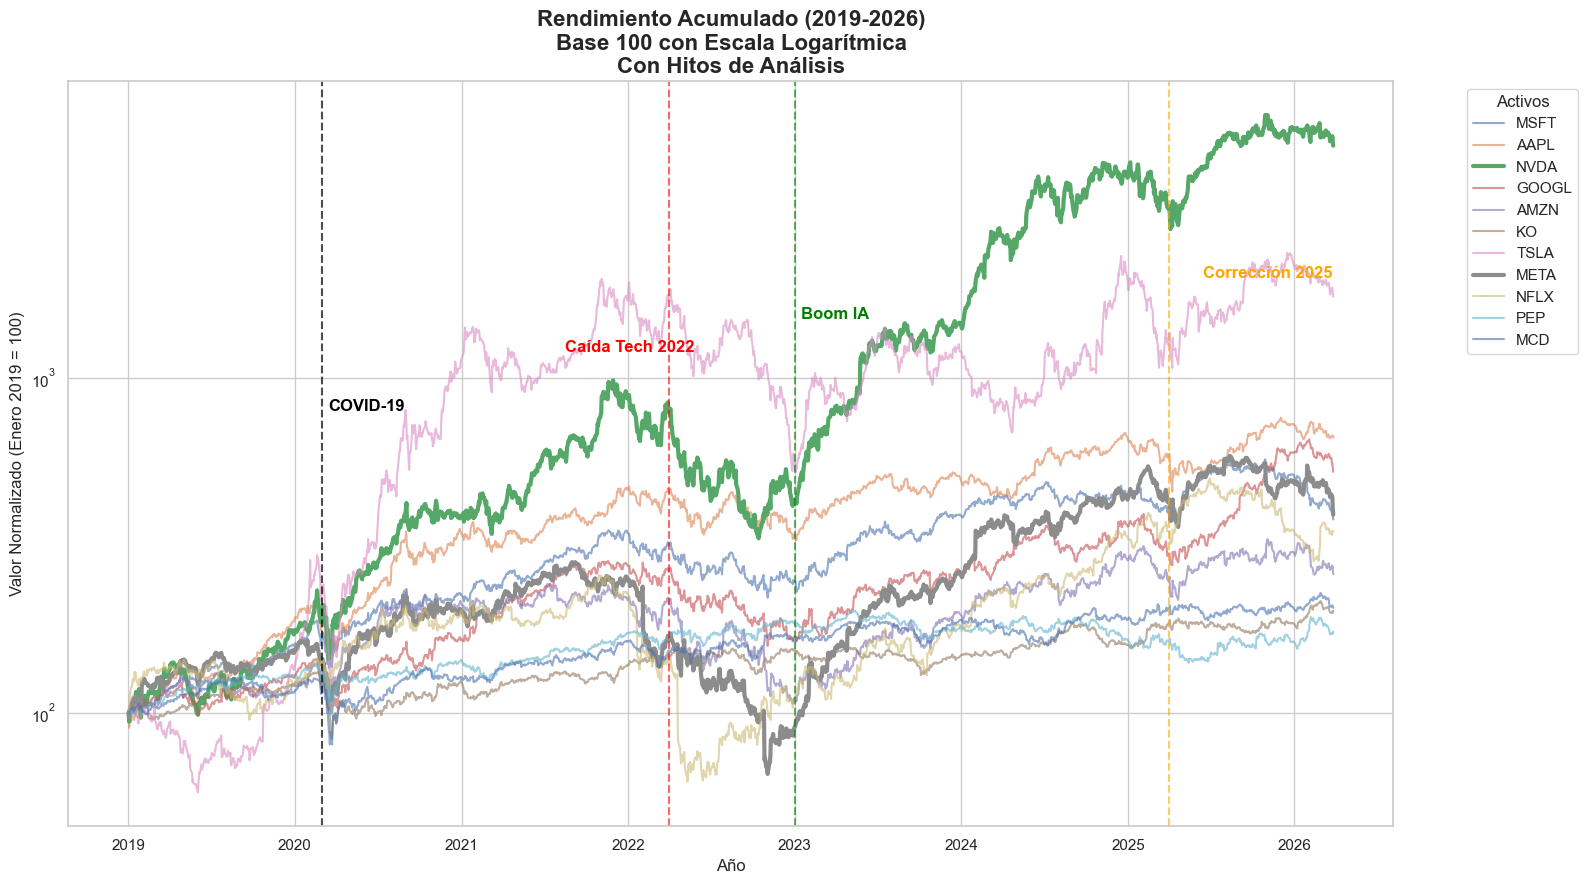

In [20]:
#4.2 Visualización Libre: Rendimiento Acumulado (Base 100) ---

# 1. Filtramos desde 2019 para ver el impacto prepandemia y post-IA
df_periodo = df_snp[df_snp['Date'] >= '2019-01-01'].copy()

# 2. Normalizamos a Base 100 (todas las acciones parten con valor 100 el primer día)
# Seleccionamos solo las columnas de precio de cierre
df_precios = df_periodo.set_index('Date').filter(like='_Close')
df_norm = (df_precios / df_precios.iloc[0]) * 100

# 3. Configuración del Gráfico
plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

# Graficamos cada activo (usamos un bucle para todas las columnas)
for col in df_norm.columns:
    ticker = col.replace('_Close', '')
    # Resaltamos NVIDIA y META por su relevancia en nuestro análisis
    lw = 3.0 if ticker in ['NVDA', 'META'] else 1.5
    alpha = 1.0 if ticker in ['NVDA', 'META'] else 0.6
    plt.plot(df_norm.index, df_norm[col], label=ticker, linewidth=lw, alpha=alpha)

# 4. AGREGAMOS LOS HITOS DE ANÁLISIS (Requisito de la rúbrica)
# Línea Pandemia (Marzo 2020)
plt.axvline(pd.Timestamp('2020-03-01'), color='black', linestyle='--', alpha=0.7)
plt.text(pd.Timestamp('2020-03-15'), 800, 'COVID-19', fontweight='bold', color='black')

# Línea Caída 2022 (Inflación/Tasas)
plt.axvline(pd.Timestamp('2022-04-01'), color='red', linestyle='--', alpha=0.6)
plt.text(pd.Timestamp('2021-08-15'), 1200, 'Caída Tech 2022', color='red', fontweight='bold')

# Línea Auge IA 2023 (ChatGPT / Chips)
plt.axvline(pd.Timestamp('2023-01-01'), color='green', linestyle='--', alpha=0.6)
plt.text(pd.Timestamp('2023-01-15'), 1500, 'Boom IA', color='green', fontweight='bold')

# Línea Corrección 2025
plt.axvline(pd.Timestamp('2025-04-01'), color='orange', linestyle='--', alpha=0.6)
plt.text(pd.Timestamp('2025-06-15'), 2000, 'Corrección 2025', color='orange', fontweight='bold')

# 5. Formato Final
plt.title('Rendimiento Acumulado (2019-2026)\nBase 100 con Escala Logarítmica\nCon Hitos de Análisis', fontsize=16, fontweight='bold')
plt.ylabel('Valor Normalizado (Enero 2019 = 100)')
plt.xlabel('Año')
plt.yscale('log') # Escala logarítmica para ver crecimientos relativos
plt.legend(title="Activos", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Análisis de la Serie Temporal e Identificación de Hitos Históricos

Al observar la evolución de los precios de cierre entre 2010 y 2026, identificamos tres periodos críticos que validan nuestras hipótesis y explican las anomalías detectadas en el EDA:

1. **El Shock de la Pandemia (Febrero - Marzo 2020):**
   * **Observación:** Se identifica un quiebre brusco en todas las series exactamente en **marzo de 2020**. 
   * **Análisis:** Es el punto de mayor caída sincronizada del gráfico. Sin embargo, lo más llamativo es la velocidad de recuperación: mientras que el grupo de consumo (KO, PEP) retomó su senda plana, empresas como **Apple** y **Microsoft** iniciaron un ascenso vertical inmediato, demostrando que el confinamiento actuó como un catalizador para el sector tecnológico.

2. **La Caída de las Empresas Tecnológicas (Todo el año 2022):**
   * **Observación:** Se observa un valle pronunciado durante **2022**, afectando principalmente a **Meta** (línea gris) y **Tesla** (línea cian). 
   * **Análisis:** Este periodo coincide con el aumento de las tasas de interés y la inflación global. Aquí se hace evidente la **super-anomalía de META** que detectamos en las estadísticas: su caída fue mucho más profunda que la del resto, perdiendo casi el 50% de su valor en pocos meses antes de su recuperación explosiva en 2023.

3. **La Explosión de la IA y el Dominio de Meta (2023 - 2026):**
   * **Observación:** A partir de **enero de 2023**, se observa un despegue masivo en el precio de **Meta** y **Microsoft**, alcanzando techos históricos cercanos a los **788 USD** y **539 USD** respectivamente.
   * **Análisis:** Este fenómeno responde directamente a nuestra hipótesis sobre el auge de la Inteligencia Artificial. Es fascinante notar cómo la magnitud de este crecimiento hace que empresas tradicionalmente "exitosas" como **Coca-Cola** parezcan líneas planas en la base del gráfico, confirmando que la brecha de riqueza entre el sector consumo y el tech se ha vuelto extrema en la última década.

4. **La Corrección de Mercado Post-IA (2025):**
   * **Observación:** Se identifica un descenso pronunciado en las valoraciones de tecnologicas durante **2025**. 
   * **Análisis:** Tras alcanzar sus máximos en ese periodo, el mercado experimentó una caida significativa. Este punto es clave porque demuestra que incluso el "Boom de la IA" tiene límites. Es interesante notar que, mientras las tecnológicas caían con fuerza, las empresas de consumo como **Pepsi** y **McDonald's** mantuvieron su trayectoria ascendente de baja pendiente, reafirmando su rol como activos defensivos en periodos de ajuste.

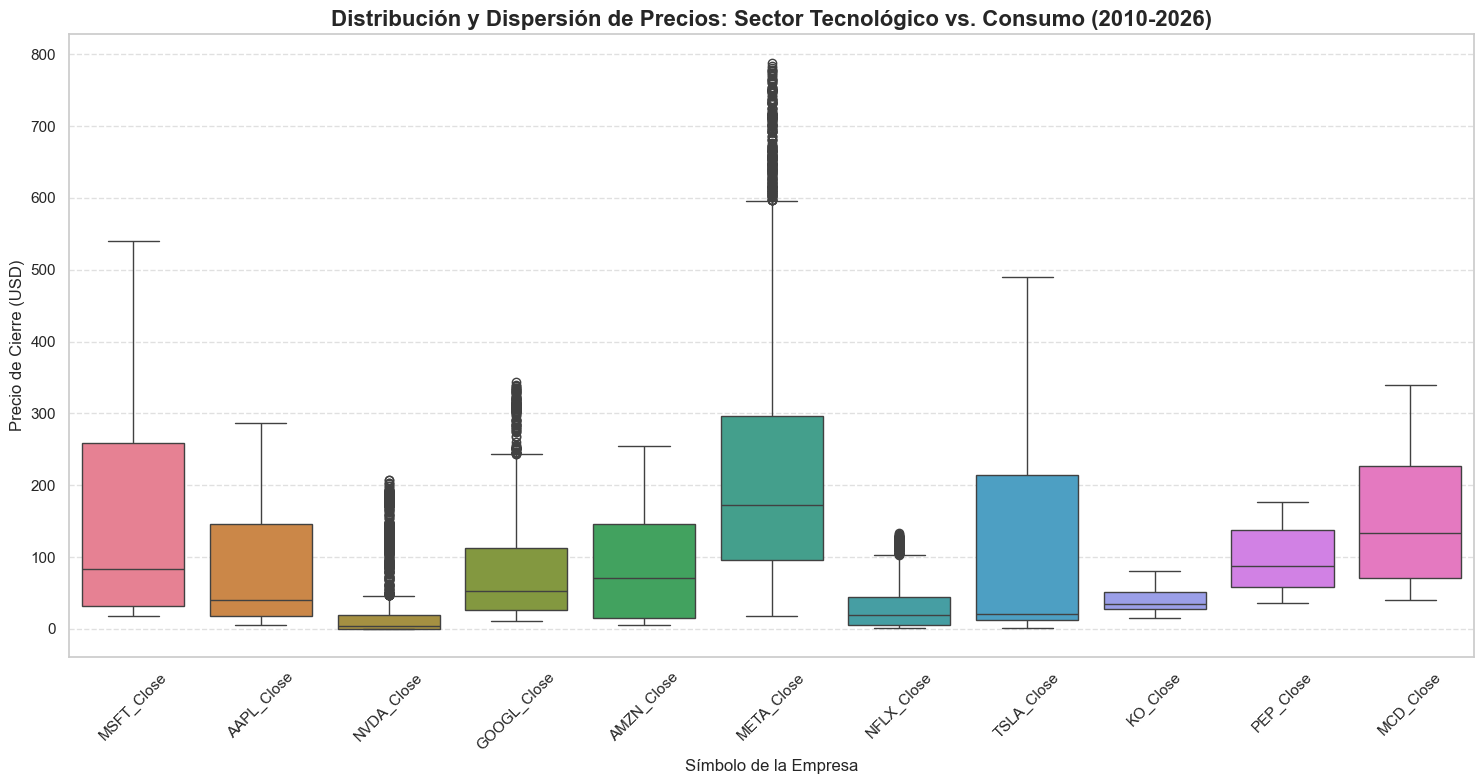

In [21]:
#4.3 Comparación entre Grupos: Boxplot de Precios

# 1. Definimos el orden para que Tech y Consumo queden agrupados
tech_list = ['MSFT', 'AAPL', 'NVDA', 'GOOGL', 'AMZN', 'META', 'NFLX', 'TSLA']
staples_list = ['KO', 'PEP', 'MCD']
cols_ordenadas = [f"{t}_Close" for t in tech_list + staples_list]

# 2. Configuramos el gráfico
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_snp[cols_ordenadas])

# 3. Personalización
plt.title("Distribución y Dispersión de Precios: Sector Tecnológico vs. Consumo (2010-2026)", fontsize=16, fontweight='bold')
plt.ylabel("Precio de Cierre (USD)", fontsize=12)
plt.xlabel("Símbolo de la Empresa", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 4. Mostramos el resultado
plt.tight_layout()
plt.show()

### 4.2 Comparación entre Grupos: Análisis de Dispersión y Volatilidad

Este **Boxplot** permite visualizar la distribución de los precios de cierre para cada activo, facilitando la comparación de riesgo entre los dos sectores estudiados:

1. **Los Líderes de Volatilidad (Meta, Microsoft y Tesla):** El gráfico confirma que estas tres empresas poseen las "cajas" más grandes del estudio. 
   * **Meta** destaca con la dispersión más extrema, pero **Microsoft** y **Tesla** también muestran cajas muy amplias, lo que indica que sus precios han recorrido rangos de valor gigantescos durante el periodo 2010-2026. Esto valida nuestra hipótesis de que el sector tech no tiene un "precio base" estable, sino que evoluciona constantemente hacia nuevos niveles de valoración.

2. **La Sorpresa de McDonald's:** Resulta llamativo que, dentro del grupo de consumo, **McDonald's (MCD)** presenta una caja relativamente grande en comparación con Coca-Cola o Pepsi. 
   * **Análisis:** Esto sugiere que, aunque es una empresa de consumo masivo, McDonald's ha tenido un crecimiento sostenido y una revalorización mucho más potente que el resto de su grupo, alejándose de la estabilidad "plana" de sus pares.

3. **Cajas Compactas (Coca-Cola, Netflix y Nvidia):** Identificamos que estas tres empresas presentan las cajas más pequeñas y "aplastadas" del gráfico, pero por razones distintas:
   * **Coca-Cola (KO):** Su caja es pequeña debido a su bajísima volatilidad histórica (std: 15.14), confirmando su rol como activo ultra-estable.
   * **Nvidia (NVDA) y Netflix (NFLX):** Sus cajas son pequeñas porque, a pesar de sus precios máximos actuales, pasaron la gran mayoría de la década (más del 50% del tiempo) en valores muy bajos. Como vimos en el EDA, la mediana de Nvidia es de apenas **4.07**, lo que "comprime" su caja en la parte inferior del gráfico a pesar de sus crecimientos explosivos recientes.

4. **Conclusión de la Comparativa:** El gráfico demuestra que tener un precio alto no siempre significa tener una caja grande. La amplitud de la caja nos cuenta la historia de cuánto ha cambiado la empresa: mientras **Meta** ha sido una montaña rusa de precios, **Nvidia** ha sido una empresa que solo despertó al final de la muestra.

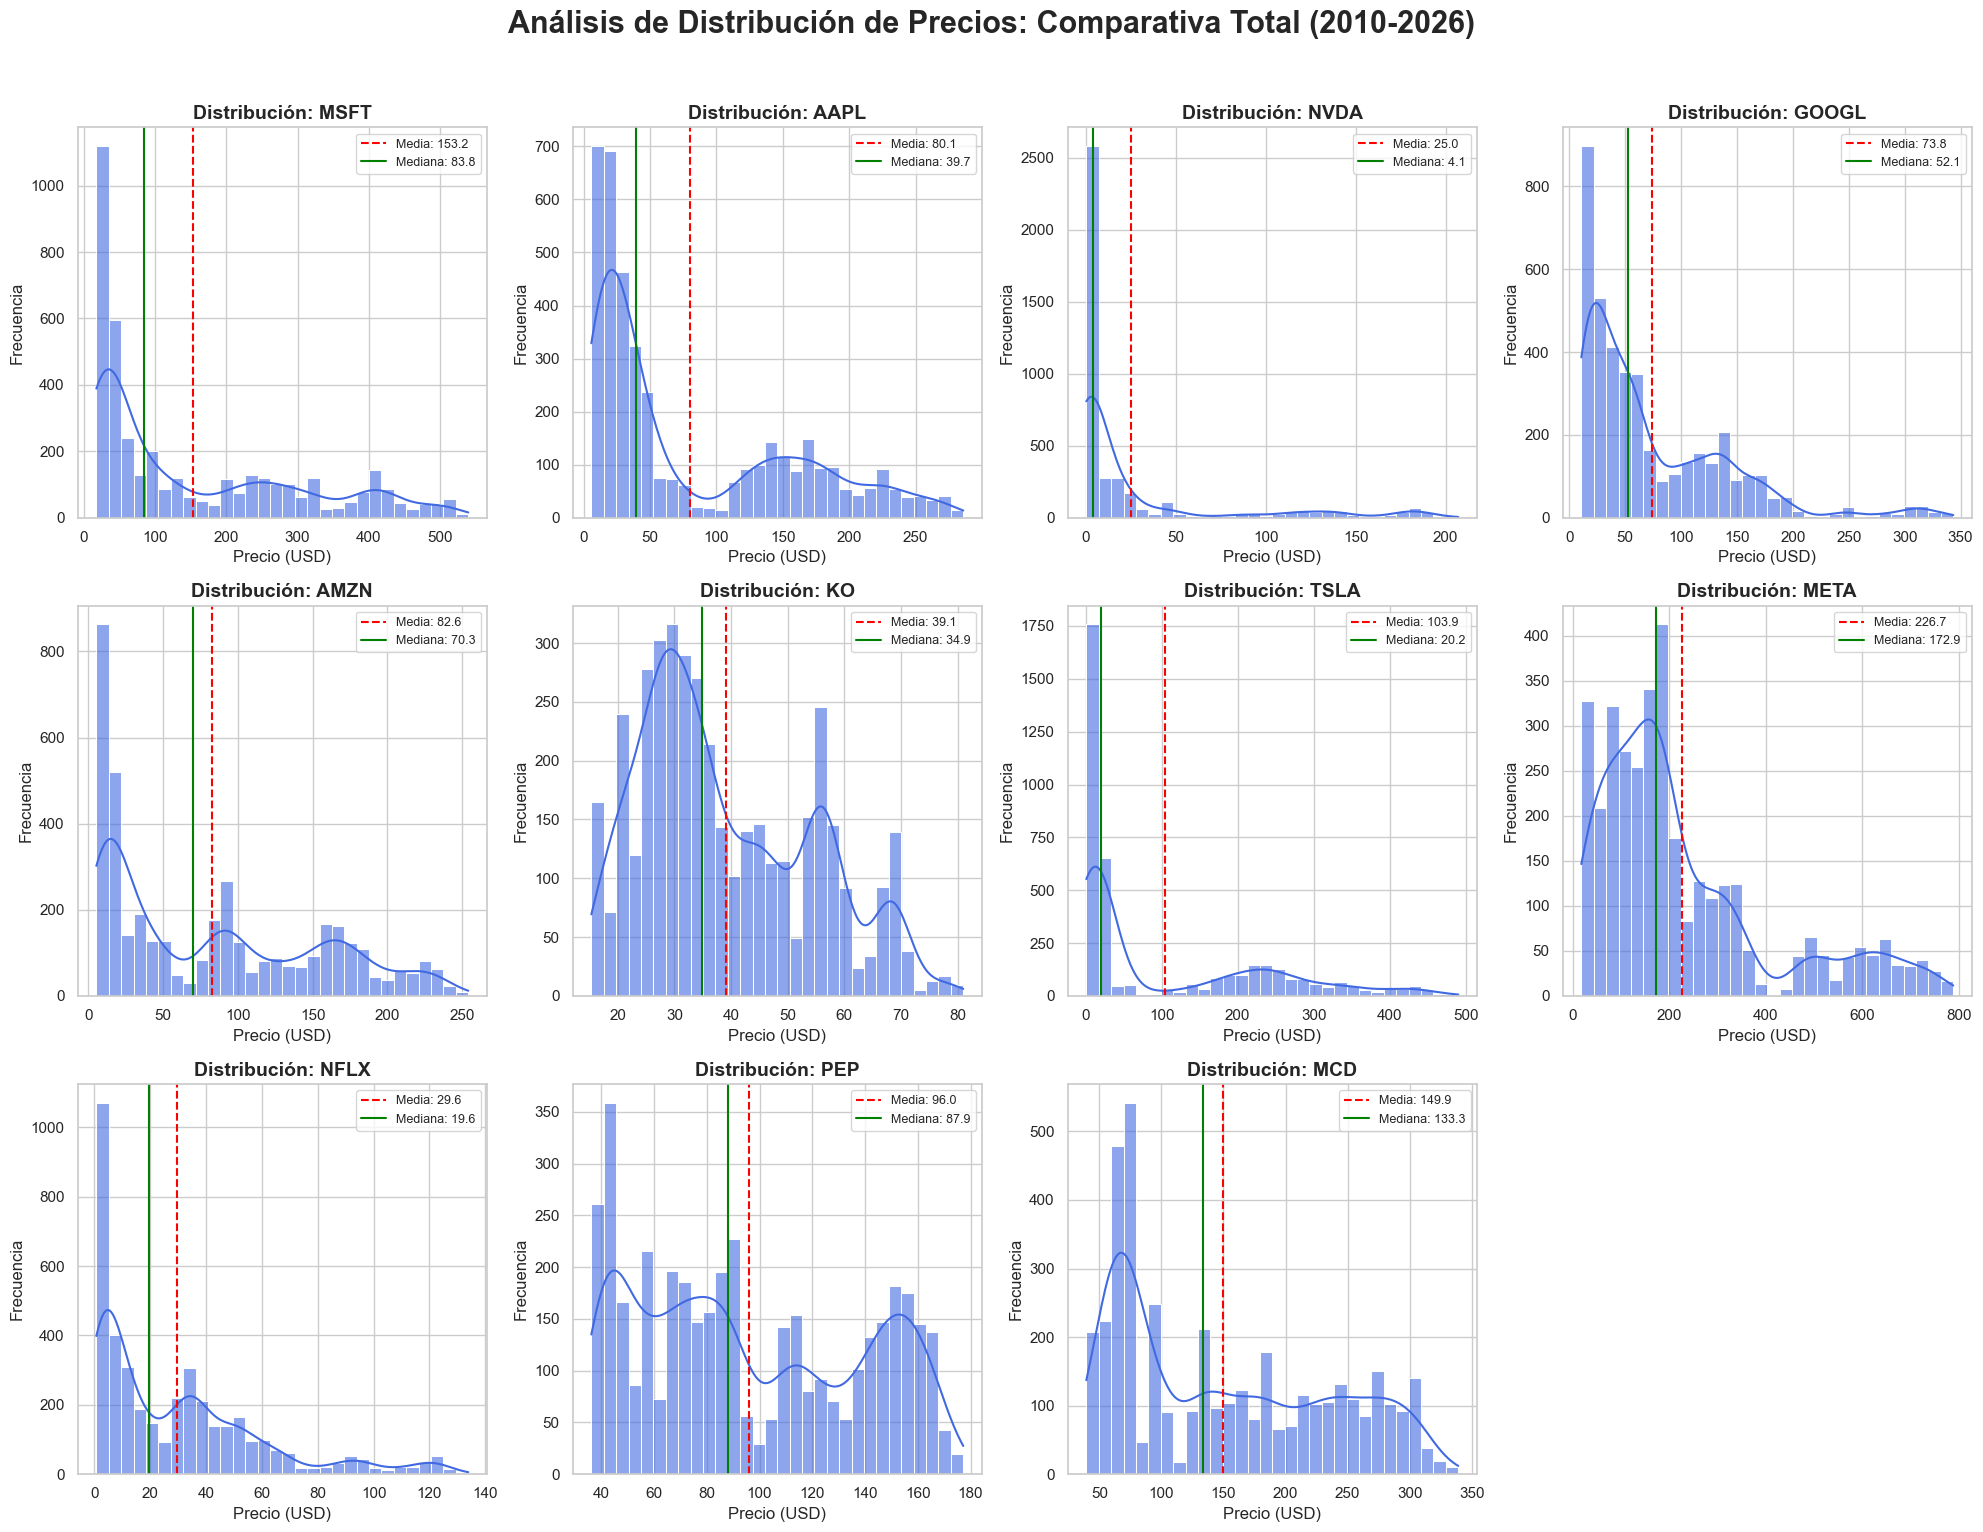

In [22]:
#4.4 Distribución de Variable: Histogramas de todas las empresas

# 1. Obtenemos los nombres de todas las empresas (quitando el '_Close')
empresas = [col.replace('_Close', '') for col in df_snp.filter(like='_Close').columns]

# 2. Configuramos la cuadrícula (4 columnas para que quepa bien en la pantalla)
n_cols = 4
n_rows = (len(empresas) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# 3. Iteramos por cada empresa para crear su histograma individual
for i, ticker in enumerate(empresas):
    col_name = f"{ticker}_Close"
    data = df_snp[col_name].dropna()
    
    # Calculamos estadísticas
    media = data.mean()
    mediana = data.median()
    
    # Dibujamos el histograma en el sub-gráfico correspondiente
    sns.histplot(data, kde=True, ax=axes[i], color='royalblue', alpha=0.6, bins=30)
    
    # Añadimos las líneas de Media y Mediana
    axes[i].axvline(media, color='red', linestyle='--', linewidth=1.5, label=f"Media: {media:.1f}")
    axes[i].axvline(mediana, color='green', linestyle='-', linewidth=1.5, label=f"Mediana: {mediana:.1f}")
    
    # Configuración de cada cuadrito
    axes[i].set_title(f"Distribución: {ticker}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Precio (USD)")
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend(fontsize=9)

# 4. Eliminamos los cuadros vacíos si sobran
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Análisis de Distribución de Precios: Comparativa Total (2010-2026)", fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4.3 Distribución de Variable: El Fenómeno de la Asimetría Positiva

Al observar la comparativa total de histogramas, podemos analizar cómo se distribuyen los precios a lo largo del tiempo. Este gráfico es vital para identificar qué activos han sufrido cambios de paradigma disruptivos frente a aquellos con crecimiento lineal:

### 1. La Doble Anomalía: NVIDIA (NVDA) y Tesla (TSLA)
Al comparar todos los activos, **NVIDIA** y **Tesla** destacan por presentar comportamientos prácticamente idénticos en su distribución de frecuencias.
* **Comportamiento:** Ambas presentan una "montaña" masiva de datos en la base (precios bajos) y una "cola" extremadamente larga y delgada hacia la derecha.
* **Interpretación:** Esto confirma que ambas fueron empresas de "valor dormido" durante la mayor parte de la década. La enorme distancia entre la **Mediana (línea verde)** y la **Media (línea roja)** en ambos gráficos indica que sus éxitos actuales (IA para Nvidia y Electromovilidad para Tesla) son eventos estadísticamente extraordinarios que "tiran" del promedio hacia arriba, pero no representan la realidad histórica de la mayoría de los días de mercado.

### 2. Contraste de Sectores: Tech vs. Consumo
* **Sector Consumo (KO, PEP, MCD):** Sus histogramas muestran campanas mucho más anchas y repartidas. La distancia entre su media y mediana es mínima en comparación con las tecnológicas, lo que indica un crecimiento **orgánico y predecible**. No hay "saltos" disruptivos, sino una acumulación constante de valor.
* **Sector Tech Maduro (AAPL, MSFT):** A diferencia de Nvidia, empresas como Apple muestran una distribución un poco más equilibrada, aunque mantienen el sesgo. Esto sugiere que son empresas que ya han consolidado su valor en niveles superiores de forma más estable que los "disruptores" puros como Tesla.

### 3. Conclusión: La Trampa del Promedio en Activos Disruptivos
Esta distribución nos revela una conclusión clave: para empresas como **NVDA** y **TSLA**, el **promedio histórico es un indicador engañoso**. 
Dado que sus precios actuales están en la "cola extrema" de la distribución, el valor de la acción hoy no tiene ninguna relación con su comportamiento pasado. Esto nos confirma que estamos ante activos impulsados por **disrupciones tecnológicas específicas** (como la IA o los Vehículos Eléctricos) y no por una tendencia de crecimiento promedio estable en el tiempo.

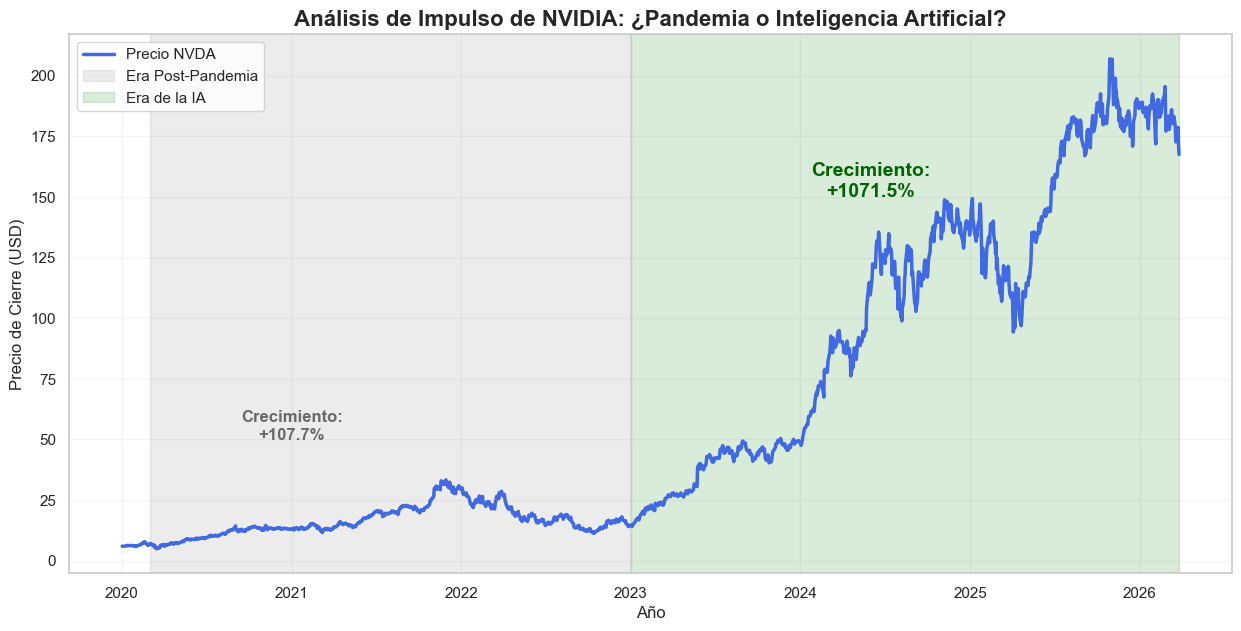

In [23]:
#4.5 Visualización Libre: Análisis de Impulso de NVIDIA: ¿Pandemia o Inteligencia Artificial?
# 1. Preparamos los datos de NVIDIA desde 2020
nvda_data = df_snp[df_snp['Date'] >= '2020-01-01'][['Date', 'NVDA_Close']].copy()

# 2. Definimos los puntos de control
p_inicio = nvda_data[nvda_data['Date'] >= '2020-03-01'].iloc[0] # Inicio Pandemia
p_pre_ia = nvda_data[nvda_data['Date'] >= '2022-12-31'].iloc[0] # Fin 2022 / Pre-IA
p_final = nvda_data.iloc[-1] # Último dato 2026

# 3. Calculamos crecimientos porcentuales
crecimiento_pandemia = ((p_pre_ia['NVDA_Close'] / p_inicio['NVDA_Close']) - 1) * 100
crecimiento_ia = ((p_final['NVDA_Close'] / p_pre_ia['NVDA_Close']) - 1) * 100

# 4. Graficamos
plt.figure(figsize=(15, 7))
plt.plot(nvda_data['Date'], nvda_data['NVDA_Close'], color='royalblue', linewidth=2.5, label='Precio NVDA')

# Sombras de las dos Eras
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2022-12-31'), color='gray', alpha=0.15, label='Era Post-Pandemia')
plt.axvspan(pd.Timestamp('2023-01-01'), nvda_data['Date'].max(), color='green', alpha=0.15, label='Era de la IA')

# Etiquetas de crecimiento
plt.text(pd.Timestamp('2021-01-01'), 50, f'Crecimiento:\n+{crecimiento_pandemia:.1f}%', 
         fontsize=12, fontweight='bold', color='dimgray', ha='center')
plt.text(pd.Timestamp('2024-06-01'), 150, f'Crecimiento:\n+{crecimiento_ia:.1f}%', 
         fontsize=14, fontweight='bold', color='darkgreen', ha='center')

# Formato profesional
plt.title('Análisis de Impulso de NVIDIA: ¿Pandemia o Inteligencia Artificial?', fontsize=16, fontweight='bold')
plt.ylabel('Precio de Cierre (USD)')
plt.xlabel('Año')
plt.legend(loc='upper left')
plt.grid(alpha=0.2)

plt.show()

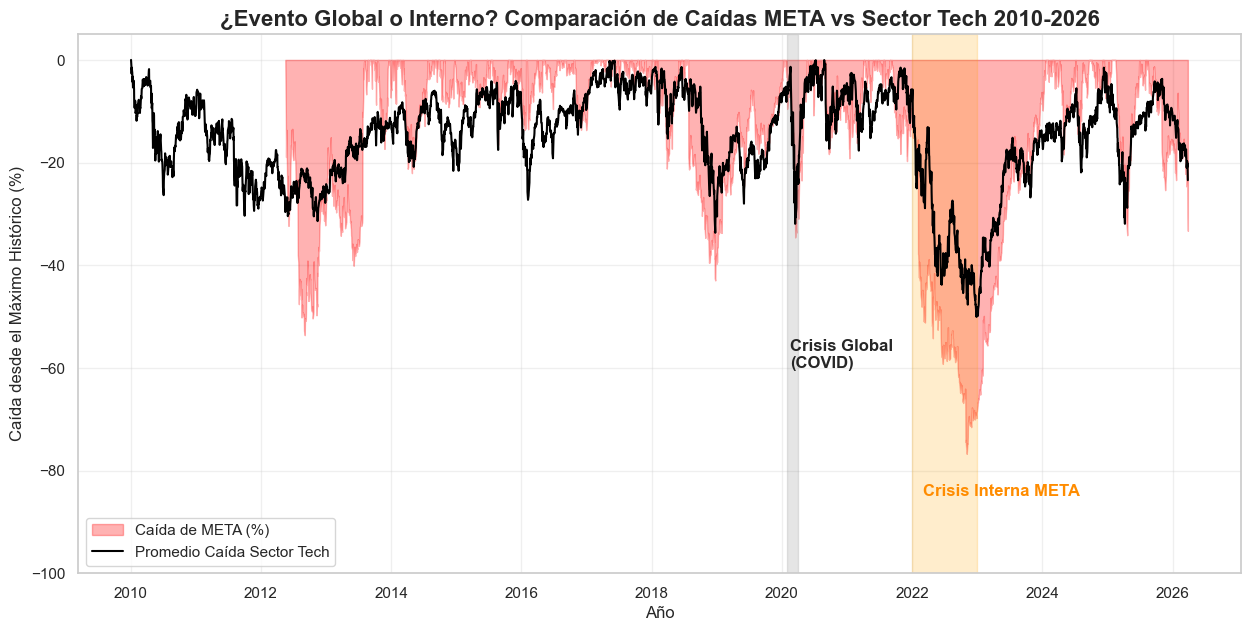

In [24]:
#4.6 Visualización Analítica: Meta vs. Mercado Tech: ¿Evento Global o Crisis Interna?

# 1. Definimos Meta y el resto del grupo Tech (sin Meta) para comparar
meta_col = 'META_Close'
otros_tech = ['MSFT_Close', 'AAPL_Close', 'NVDA_Close', 'GOOGL_Close', 'AMZN_Close', 'NFLX_Close', 'TSLA_Close']

# 2. Calculamos el Drawdown: (Precio Actual / Máximo Histórico hasta la fecha) - 1
# Esto nos da el % de caída desde el pico.
df_drawdown = df_snp.set_index('Date').copy()

def get_drawdown(series):
    rolling_max = series.cummax()
    return (series / rolling_max) - 1

meta_dd = get_drawdown(df_drawdown[meta_col])
tech_avg_dd = df_drawdown[otros_tech].apply(get_drawdown).mean(axis=1)

# 3. Graficamos
plt.figure(figsize=(15, 7))
plt.fill_between(meta_dd.index, meta_dd * 100, color="red", alpha=0.3, label='Caída de META (%)')
plt.plot(tech_avg_dd.index, tech_avg_dd * 100, color="black", linewidth=1.5, label='Promedio Caída Sector Tech')

# 4. Marcamos los hitos para responder la pregunta
# Crisis COVID
plt.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'), color='gray', alpha=0.2)
plt.text(pd.Timestamp('2020-02-15'), -60, 'Crisis Global\n(COVID)', fontweight='bold')

# Crisis Interna META (Metaverso/Privacidad)
plt.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'), color='orange', alpha=0.2)
plt.text(pd.Timestamp('2022-03-01'), -85, 'Crisis Interna META', color='darkorange', fontweight='bold')

# Formato
plt.title('¿Evento Global o Interno? Comparación de Caídas META vs Sector Tech 2010-2026', fontsize=16, fontweight='bold')
plt.ylabel('Caída desde el Máximo Histórico (%)')
plt.xlabel('Año')
plt.legend()
plt.ylim(-100, 5) # El límite es -100% (pérdida total)
plt.grid(alpha=0.3)

plt.show()

## 4.4 Respuesta a Preguntas Analíticas: Casos Críticos (NVIDIA y META)

Tras realizar un análisis de impulso y una comparativa de caídas acumuladas, podemos dar respuesta a las preguntas de investigacion planteadas en la seccion `3.1`:

### 1. El Motor del Crecimiento de NVIDIA: ¿Pandemia o IA?
Al observar el gráfico de **Análisis de Impulso**, la evidencia es contundente para resolver nuestra primera pregunta analítica:

* **Era Post-Pandemia (+107.7%):** Entre 2020 y finales de 2022, NVIDIA tuvo un crecimiento notable impulsado por la digitalización y el mercado de *gaming*. Sin embargo, estadísticamente, este periodo se visualiza como una etapa de preparación.
* **Era de la IA (2023 Hasta Actualidad):** El salto hacia los máximos históricos de **207.01 USD** ocurre con un ángulo de inclinación mucho más agudo a partir de **enero de 2023**.
* **Conclusión:** El "Boom de la IA" generó un crecimiento **más del doble de potente** que el de la pandemia. Esto confirma que la anomalía detectada en el EDA (donde la media de **24.99** es 6 veces la mediana) se debe casi exclusivamente a la disrupción tecnológica de 2023 y no a una inercia previa.

---

### 2. La Anomalía de META: ¿Crisis Global o Riesgo Interno?
El gráfico de **Comparación de Drawdowns** nos permite diseccionar el nivel de riesgo récord de META (**std: 184.84**) y entender su origen:

* **Sincronía en 2020:** Durante la crisis del COVID-19, la caída de **META** (rojo) y la del **Promedio Tech** (negro) fueron idénticas. En este punto, su volatilidad era sistémica y respondía a factores globales.
* **Divergencia Crítica en 2022:** Aquí encontramos la respuesta. Mientras que el sector tecnológico promedio cayó un **-50%** aprox, META colapsó hasta casi un **-80%**. Esta brecha masiva coincide con el cambio de modelo de negocio hacia el Metaverso y las restricciones de privacidad de Apple.
* **Conclusión:** La extrema volatilidad de META no es provocada por el mercado global, sino por **factores internos y cambios de paradigma propios**. Esto la define como el activo más impredecible del estudio: es capaz de caer más que sus pares ante dudas sobre su ejecución interna.

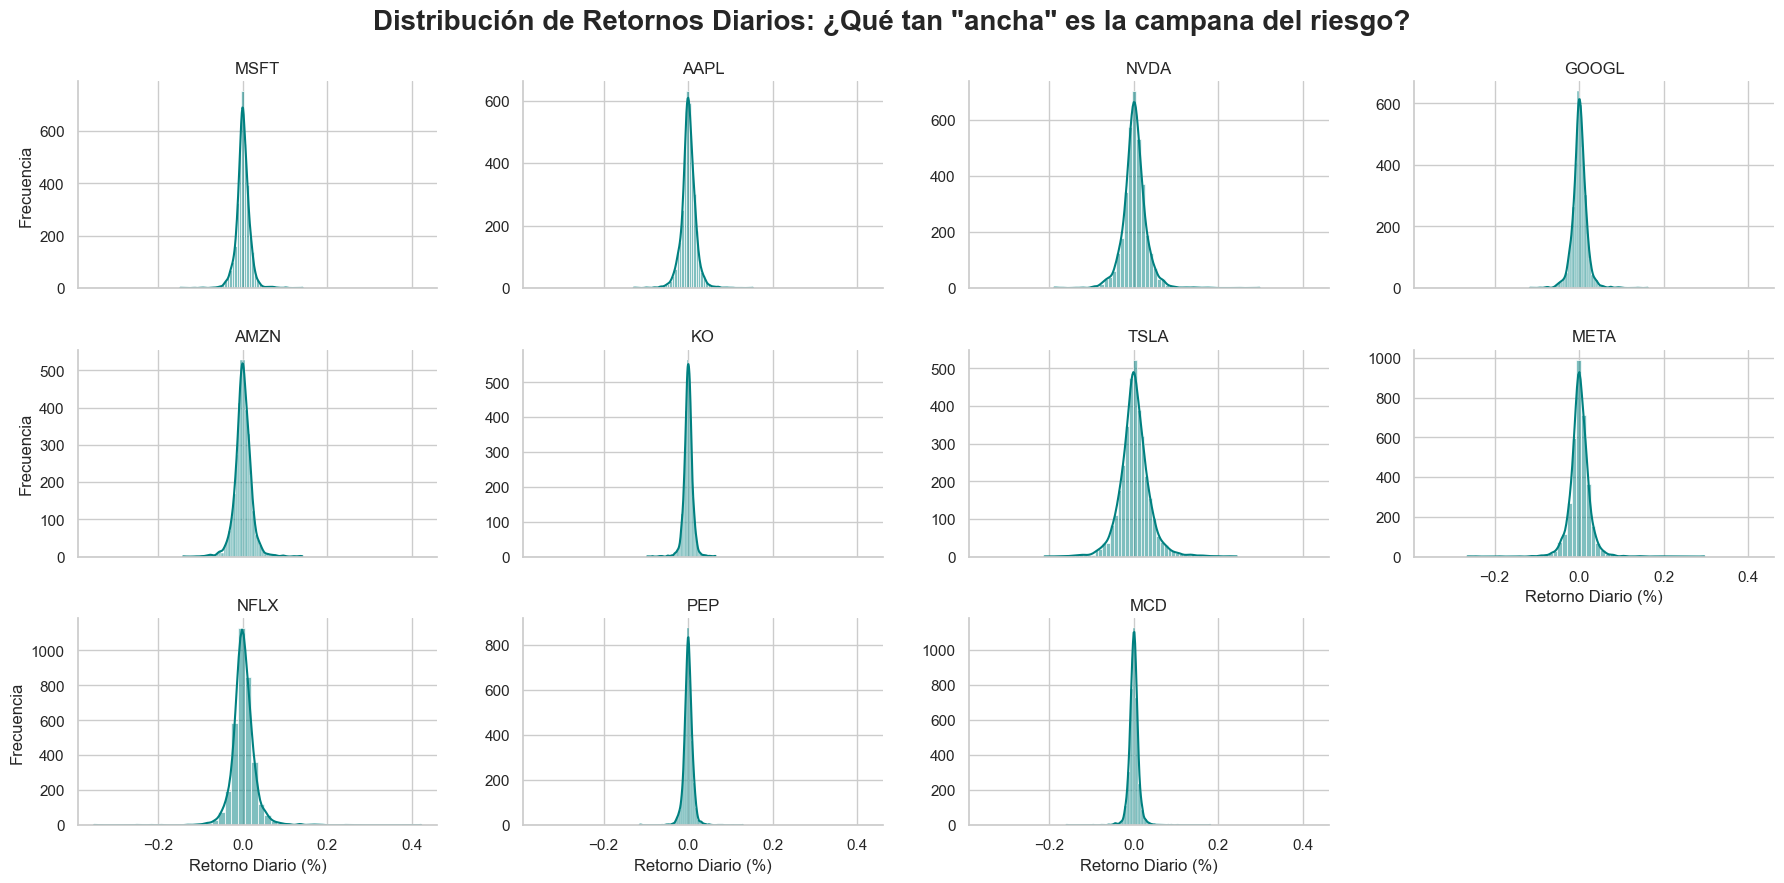

In [25]:
#4.7 Visualización Extra: Comparativa de Retornos Diarios (Riesgo)

# 1. Calculamos el retorno diario (cambio porcentual)
# El primer valor será NaN, así que lo eliminamos con .dropna()
df_retornos = df_snp.set_index('Date').filter(like='_Close').pct_change().dropna()

# 2. Transformamos los datos a formato "largo" para Seaborn (Melt)
df_melted = df_retornos.melt(var_name='Empresa', value_name='Retorno_Diario')
df_melted['Empresa'] = df_melted['Empresa'].str.replace('_Close', '')

# 3. Creamos la cuadrícula de gráficos (FacetGrid)
g = sns.FacetGrid(df_melted, col="Empresa", col_wrap=4, sharex=True, sharey=False, height=3, aspect=1.5)

# 4. Dibujamos los histogramas con KDE en cada cuadrito
g.map(sns.histplot, "Retorno_Diario", kde=True, color="teal", bins=50)

# 5. Ajustes estéticos y títulos
g.set_axis_labels("Retorno Diario (%)", "Frecuencia")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribución de Retornos Diarios: ¿Qué tan "ancha" es la campana del riesgo?', fontsize=20, fontweight='bold')

plt.show()

## 5. Interpretación de resultados

### Contraste con la hipótesis inicial

A partir de las hipótesis planteadas antes del análisis, se puede evaluar qué tan bien se ajustan a los patrones observados en los datos.

**Hipótesis 1: Shock de la pandemia (marzo 2020)**  
Esta hipótesis se cumple en gran medida. En la serie temporal se observa una caída abrupta en marzo de 2020 en prácticamente todos los activos analizados, lo que confirma la existencia de un quiebre global en ese periodo.  
Sin embargo, la recuperación no es completamente uniforme: si bien algunas empresas tecnológicas muestran una recuperación más rápida, esta no es instantánea ni idéntica entre todas ellas, lo que matiza la idea de una ventaja homogénea del sector.

---

**Hipótesis 2: Auge de la inteligencia artificial (2023–2024)**  
Se observa un crecimiento relevante en empresas tecnológicas durante este periodo, lo que es consistente con la hipótesis inicial. En particular, algunos activos presentan pendientes de crecimiento más pronunciadas en comparación con etapas anteriores.  
No obstante, el efecto no es completamente aislado ni exclusivo, ya que otros activos también muestran tendencias positivas, lo que sugiere que el fenómeno podría estar influido por condiciones generales del mercado además del desarrollo tecnológico.

---

**Hipótesis 3: Diferencia de volatilidad entre sectores**  
Esta hipótesis se ve respaldada al analizar los retornos diarios. Los activos tecnológicos presentan una mayor dispersión en sus retornos, evidenciando fluctuaciones más intensas en el corto plazo.  
Por otro lado, activos del sector de consumo muestran distribuciones más concentradas, lo que indica un comportamiento más estable. Esto confirma que existen diferencias relevantes en el nivel de riesgo entre sectores, aunque estas diferencias se observan de forma más clara al trabajar con retornos y no con precios absolutos.

---

**Hipótesis 4: Caída por inflación (2022)**  
Durante el año 2022 se identifica un periodo en el que varios activos presentan caídas o desaceleraciones en su crecimiento, lo que es consistente con la hipótesis planteada.  
Sin embargo, esta caída no es perfectamente sincronizada ni de igual magnitud entre todos los activos, lo que sugiere que el impacto de este periodo varía dependiendo del activo específico.

---

### Síntesis general

En conjunto, las hipótesis se cumplen parcialmente: los eventos globales relevantes (como 2020 y 2022) sí se reflejan en los datos, pero con matices importantes en términos de magnitud, duración y comportamiento entre activos.  

Esto muestra que, si bien la intuición inicial permite anticipar tendencias generales, el análisis de datos revela una mayor complejidad en los patrones observados, especialmente en la comparación entre distintos tipos de activos.

---

### Hallazgos inesperados

Un resultado que no se anticipaba completamente fue la magnitud de la variabilidad en los retornos diarios. Al analizar los retornos, se observa que existen fluctuaciones considerables incluso en períodos donde el precio general parece estable.

Además, se identificaron diferencias importantes en la dispersión de los retornos entre activos, lo que indica que no todos presentan el mismo nivel de riesgo, incluso si sus tendencias de largo plazo son similares.

Otro aspecto relevante es que algunas relaciones entre variables, como la correlación entre activos, cambian dependiendo de si se analizan precios o retornos, lo cual evidencia la importancia de elegir correctamente la métrica de análisis.

Como ultimo, un hallazgo inesperado fue el ver la caida de precio de las empresas en el año 2025, este comportamiento se puede deber a distintos factores, pero suponemos que podria estar dado por el limite que tuvo la IA.

---

### Elemento que contradice o matiza la hipótesis

Un punto que matiza la hipótesis inicial es que, aunque se esperaba que todos los activos siguieran patrones similares debido a pertenecer al mismo sector, los datos muestran diferencias claras en ciertos períodos.

Por ejemplo, durante el año 2022, algunos activos presentan caídas más pronunciadas que otros, lo que sugiere que existen factores específicos que afectan de manera distinta a cada uno. Este comportamiento no era evidente al plantear la hipótesis inicial y resalta la importancia de analizar cada serie de manera individual.

---

### Limitaciones del análisis

Una limitación importante de este análisis es que se basa únicamente en precios históricos de los activos, sin incorporar variables externas que podrían explicar los comportamientos observados (como indicadores macroeconómicos o eventos específicos del mercado).

Finalmente, no todos los activos tienen exactamente el mismo rango temporal de datos disponibles, lo que puede introducir sesgos al momento de comparar períodos específicos.